In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image

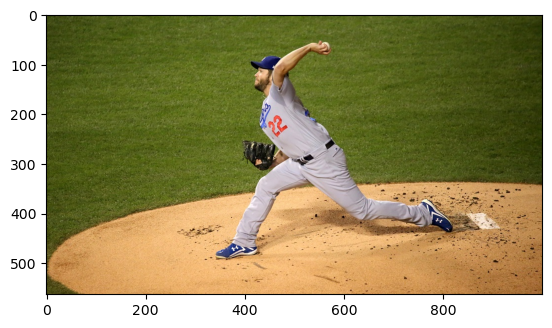

In [2]:
path='../opencvbootcamp/Clayton.jpg'
clay=cv2.imread(path,1)
#opencv defaults to bgr, most applications want rgb
clay=cv2.cvtColor(clay, cv2.COLOR_BGR2RGB)
plt.imshow(clay)

In [3]:
#run this code to download the pose estimation model

#import urllib.request

#url = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/1/pose_landmarker_heavy.task"

#note how we give the model a much shorter name
#urllib.request.urlretrieve(
#    url,
#    "pose_landmarker.task"
#)

In [4]:
#Source, from google
#https://colab.research.google.com/github/googlesamples/mediapipe/blob/main/examples/pose_landmarker/python/%5BMediaPipe_Python_Tasks%5D_Pose_Landmarker.ipynb#scrollTo=3jAIFzw9M3JJ

from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles
from mediapipe.tasks.python import vision


def draw_landmarks_on_image(rgb_image, detection_result):
  pose_landmarks_list = detection_result.pose_landmarks
  annotated_image = np.copy(rgb_image)

  pose_landmark_style = drawing_styles.get_default_pose_landmarks_style()
  pose_connection_style = drawing_utils.DrawingSpec(color=(0, 255, 0), thickness=2)

  for pose_landmarks in pose_landmarks_list:
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=pose_landmarks,
        connections=vision.PoseLandmarksConnections.POSE_LANDMARKS,
        landmark_drawing_spec=pose_landmark_style,
        connection_drawing_spec=pose_connection_style)

  return annotated_image

In [5]:
#Source, from google
#https://colab.research.google.com/github/googlesamples/mediapipe/blob/main/examples/pose_landmarker/python/%5BMediaPipe_Python_Tasks%5D_Pose_Landmarker.ipynb#scrollTo=3jAIFzw9M3JJ

# STEP 1: Import the necessary modules.
import mediapipe as mp
from mediapipe.tasks import python

# STEP 2: Create an PoseLandmarker object.

#                                                     remember the code to download the pose estimation model? we are using the model
base_options = python.BaseOptions(model_asset_path='pose_landmarker.task')
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    output_segmentation_masks=True)
detector = vision.PoseLandmarker.create_from_options(options)

# STEP 3: Load the input image.
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=clay)

# STEP 4: Detect pose landmarks from the input image.
detection_result = detector.detect(mp_image)

# STEP 5: Process the detection result. In this case, visualize it.
annotated_image = draw_landmarks_on_image(mp_image.numpy_view(), detection_result)


I0000 00:00:1773352648.078120  966475 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M4 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1773352648.109470  966476 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773352648.122528  966479 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773352648.175258  966487 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


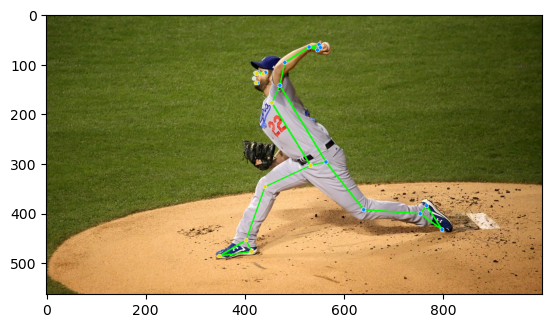

In [6]:
plt.imshow(annotated_image)

# Let's make this more ergonomic

In [7]:
def plot_landmarks_on_image(rgb_image):

  mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_image)
  detection_result = detector.detect(mp_image)
  pose_landmarks_list = detection_result.pose_landmarks
  annotated_image = np.copy(rgb_image)

  pose_landmark_style = drawing_styles.get_default_pose_landmarks_style()
  pose_connection_style = drawing_utils.DrawingSpec(color=(0, 255, 0), thickness=2)

  for pose_landmarks in pose_landmarks_list:
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=pose_landmarks,
        connections=vision.PoseLandmarksConnections.POSE_LANDMARKS,
        landmark_drawing_spec=pose_landmark_style,
        connection_drawing_spec=pose_connection_style)

  plt.imshow(annotated_image)

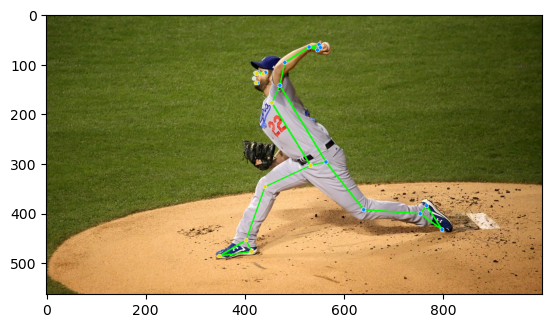

In [8]:
plot_landmarks_on_image(clay)

In [9]:
def readim(path):
    im=cv2.imread(path,1)
    data=cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    return data

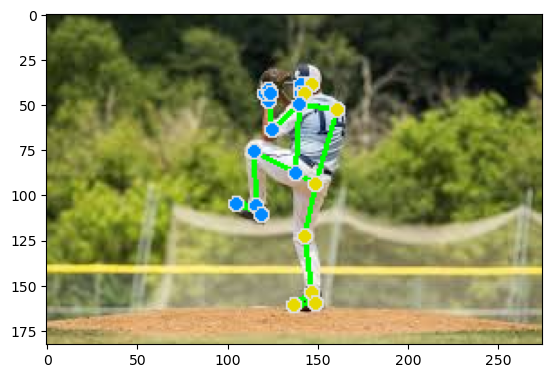

In [10]:
path='../opencvbootcamp/dbzpitch.jpeg'
dbz=readim(path)
plot_landmarks_on_image(dbz)

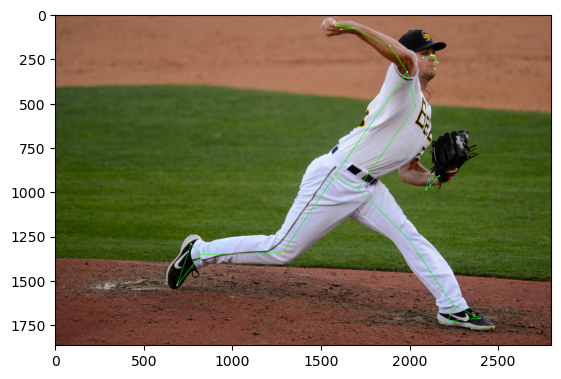

In [11]:
path='../opencvbootcamp/hurl.jpg'
dbz=readim(path)
plot_landmarks_on_image(dbz)

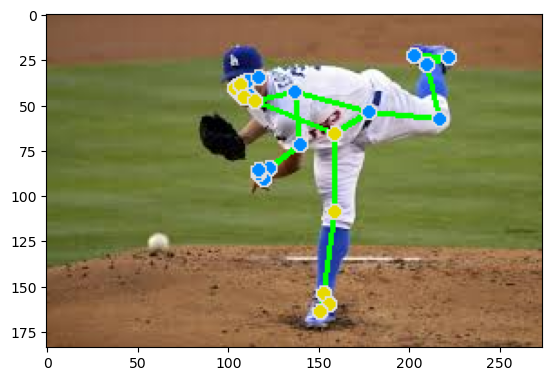

In [12]:
path='../opencvbootcamp/release.jpeg'
dbz=readim(path)
plot_landmarks_on_image(dbz)

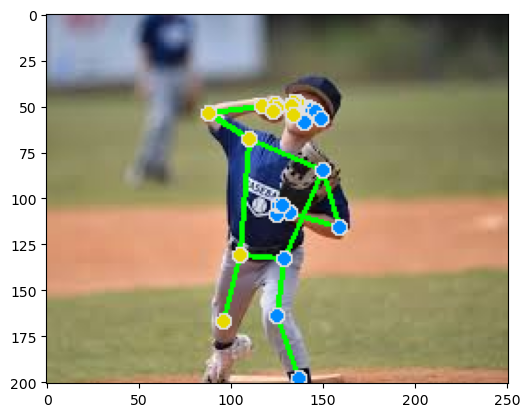

In [13]:
path='../opencvbootcamp/kiddo.jpeg'
dbz=readim(path)
plot_landmarks_on_image(dbz)